# Diffusion Model: SU3 gauge theory on $4^4$ lattice

*Sep 24, 2025*

**[Javad Komijani (ETH Zurich)](mailto:jkomijani@gmail.com)**

## Diffusion process on Lie group

Implements a diffusion process as described by the following stochastic     
    differential equation (SDE)                                                 
                                                                                
$$                                                                   
    \frac{d U(t)}{dt} = \sigma(t)\, \eta(t)\, U(t)
$$

where $\sigma(t)$ is a time-dependent noise scale, and $\eta(t)$ is standard white Gaussian noise in the algebra space.
We use
$$
    \sigma(t) = \frac{\sigma_0}{\sqrt{1 - t}}
$$                
                                                                                
The reverse process is defined by an SDE that uses a learned score function 
(the gradient of the log-probability density) to iteratively denoise the    
corrupted signal and recover clean samples.
$$                                                                   
    \frac{d U(t)}{dt} = \left(-\frac{1 + r^2}{2} \sigma^2(t) s_t(U_t) +  r \sigma(t) \eta(t)\right) U_t
$$
Here $s_t$ is in Lie-algebra element, and $r$ can be time dependent too. As two spatial cases, we can set $r$ to 0 or to 1.

Below, we define a simple neural network for the score function.

In [1]:
import torch
import numpy as np

import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams["text.usetex"] = True

## Data for training and test

We use HMC to generate $256$ samples. For now we use all for training and test.

In [2]:
training_samples = torch.load("cfgs_b6_200traj_15steps.pt")

from torch.utils.data import DataLoader, TensorDataset

batch_size = 256 // 4

dataset = TensorDataset(training_samples)

data_loader = DataLoader(
    dataset,
    batch_size = batch_size,
    shuffle = False
)

In [3]:
from lattice_ml.gauge_tools import WilsonGaugeAction

beta = 6

action = WilsonGaugeAction(beta=beta)

## Define a `DiffusionProcess`

A **diffusion process** contains a neural network that models **score function**,
which can be used to perform the reverse process.

Before we continue, let us create a dummy `DiffusionProcess` without any score
function and see the effect of the diffusion process.

In [4]:
from lattice_ml.diffusion.gauge import SUnDiffusionProcess

sigma_0 = 1 / 2

diffusion_process = SUnDiffusionProcess(score_fn=None, sigma_0=sigma_0)

t_eval = torch.linspace(0, 1, 10)

diffused_samples = diffusion_process.forward(training_samples, t_eval=t_eval)

diffused_samples = torch.stack(diffused_samples, dim=0)

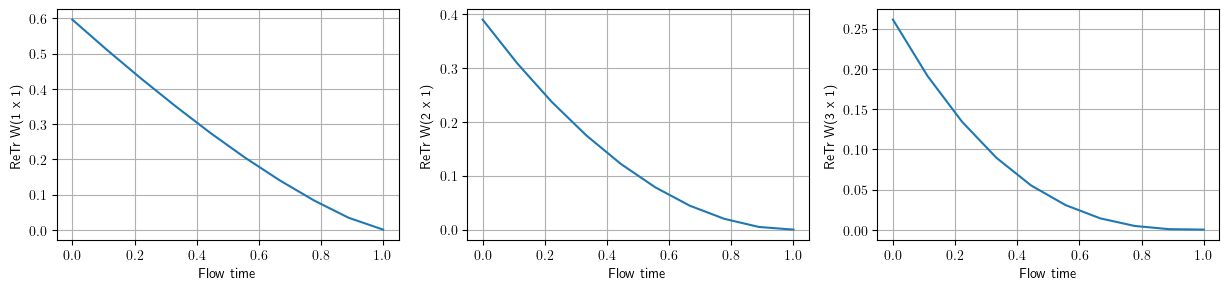

In [5]:
from lattice_ml.gauge_tools import compute_mean_reduced_trace_wilson_mxn_loop


def plot_wilson_loops(t_eval, x_eval, label=None, axs=None):

    if axs is None:
        fig, axs = plt.subplots(1, 3, figsize=(15, 3))

    for n in range(3):
        plaq = compute_mean_reduced_trace_wilson_mxn_loop(x_eval, 1 + n, 1, prefix_dims=2)
        axs[n].plot(t_eval, plaq.mean(dim=-1).real, label=label)
        axs[n].set_xlabel("Flow time")
        axs[n].set_ylabel(f"ReTr W({n + 1} x 1)")
        axs[n].grid()
        if label is not None:
            axs[n].legend()
        

plot_wilson_loops(t_eval, diffused_samples)

### Designing score function

The flow is defined as
The reverse process is defined by an SDE that uses a learned score function 
(the gradient of the log-probability density) to iteratively denoise the    
corrupted signal and recover clean samples.
$$                                                                   
    \frac{d U(t)}{dt} = \left(-\frac{1 + r^2}{2} \sigma^2(t) s_t(U_t) +  r \sigma(t) \eta(t)\right) U_t
$$
Here $s_t$ is in Lie-algebra element, and $r$ can be time dependent too. As two spatial cases, we can set $r$ to 0 or to 1.

Below, we define a simple neural network for the score function.

In [6]:
def make_traceless(matrix: torch.Tensor) -> torch.Tensor:
    """
    Project the input onto the space of traceless matrices.
    """
    # Compute the mean trace across the last two dimensions
    trace_mean = matrix.diagonal(dim1=-2, dim2=-1).mean(dim=-1, keepdim=True)
    
    # Subtract the mean trace from the diagonal elements
    return matrix - torch.diag_embed(trace_mean.expand(matrix.shape[:-1]))


class SU3AlgScoreFunc(torch.nn.Module):
    """
    An algebra-element score function for SU(3) matrices.

    This model takes as input the time `t` and the initial state matrix `x` and
    predicts a flow while ensuring the output remains antihermitian and traceless.

    The network consists of fully connected layers with SiLU activations.

    Attributes:
        net: A sequential model composed of linear layers and activations.
    """

    n_c = 3  # number of colors
    
    def __init__(self, hidden_sizes: list[int] = [32, 32, 32, 32]):
        """Initializes the SU3DynamicsFunc neural network."""
        super().__init__()

        matrix_components = self.n_c ** 2
        in_features = 1 + 2 * matrix_components  # t & complex components
        out_features = 2 * matrix_components  # complex components
        layer_sizes = [in_features, *hidden_sizes, out_features]
        layers = []

        # Construct the network layers
        for i in range(len(layer_sizes) - 1):
            layers.append(torch.nn.Linear(layer_sizes[i], layer_sizes[i + 1]))
            if i < len(layer_sizes) - 2:  # No activation for the last layer
                layers.append(torch.nn.SiLU())

        self.net = torch.nn.Sequential(*layers)

    def forward(self, t: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
        """
        Computes the algebra-element score function for SU(3) matrices.

        Given a time `t` and a matrix `x`, the function processes the input
        through the neural network and applies post-processing to ensure the
        output is antihermitian and traceless.

        Args:
            - t (torch.Tensor): A 0D or 1D tensor representing time.
              If 1D, it is of shape (batch_size,)
            - x (torch.Tensor): A real-valued input tensor of shape
              (batch_size, ..., 3).

        Returns:
            - torch.Tensor: A antihermitian, traceless tensor of shape
              (batch_size, ..., 3, 3).
        """
        input_shape = x.shape
        bsize = input_shape[0]
        n_c = input_shape[-1]
        latsize = np.prod(input_shape[1:-2])
        assert n_c == self.n_c
        
        # Ensure t is a batch tensor
        if t.ndim == 0:
            t = t.repeat(bsize)
            
        t = t[:, None].repeat(1, latsize).reshape(-1, 1)

        # Reshape x and concatenate with t
        x = torch.cat([t, torch.view_as_real(x).reshape(-1, 2*n_c**2)], dim=-1)

        # Forward pass through the network
        x = self.net(x)

        # Convert the output to a complex tensor with appropriate shape
        x = torch.view_as_complex(x.reshape(-1, n_c, n_c, 2))
        
        # Ensure the output is antihermitian and traceless
        return make_traceless(x - x.adjoint()).reshape(*input_shape)

In [7]:
from lattice_ml.gauge_tools import compute_all_directional_staples
from lattice_ml.gauge_tools import GaugeLinkConv


sigma_schedule = diffusion_process.sigma_schedule


class GaugeSU3AlgScoreFunc(torch.nn.Module):
    """
    An algebra-element score function for SU(3) matrices.

    This model takes as input the time `t` and the initial state matrix `x` and
    predicts a flow while ensuring the output remains antihermitian and traceless.
    """

    def __init__(self, beta=beta):
        """Initializes the SU3DynamicsFunc neural network."""
        super().__init__()
        self.beta = beta
        self.layers = SU3AlgScoreFunc()
        self.link_conv = torch.nn.Sequential(
            *[GaugeLinkConv(None, None, spatial_ndim=4) for _ in range(2)]
        )
        
    def forward(self, t: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
        """
        Computes the algebra-element score function for SU(3) matrices.

        Given a time `t` and a matrix `x`, the function processes the input
        through the neural network and applies post-processing to ensure the
        output is antihermitian and traceless.

        Args:
            - t (torch.Tensor): A 0D or 1D tensor representing time.
              If 1D, it is of shape (batch_size,)
            - x (torch.Tensor): A complex-valued input tensor of shape
              (batch_size, ..., 3, 3).

        Returns:
            - torch.Tensor: A antihermitian, traceless tensor of shape of x:
              (batch_size, ..., 3, 3).
        """
        # x = self.link_conv(x)
        
        score_beta1_t0 = self.layers(t, x @ compute_all_directional_staples(x))
        
        sigma_t = sigma_schedule(t).reshape(-1, *[1] * (x.ndim - 1))
        
        return self.beta * score_beta1_t0 / sigma_t ** 2

In [8]:
class GaugeSU3AlgScoreFunc(torch.nn.Module):
    """
    An algebra-element score function for SU(3) matrices.

    This model takes as input the time `t` and the initial state matrix `x` and
    predicts a flow while ensuring the output remains antihermitian and traceless.
    """

    def __init__(self):
        """Initializes the SU3DynamicsFunc neural network."""
        super().__init__()

        self.weight = torch.nn.Parameter(torch.tensor(1.0))
        self.powers = torch.arange(2).reshape(1, -1)
        
    def forward(self, t: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
        """
        Computes the algebra-element score function for SU(3) matrices.

        Given a time `t` and a matrix `x`, the function processes the input
        through the neural network and applies post-processing to ensure the
        output is antihermitian and traceless.

        Args:
            - t (torch.Tensor): A 0D or 1D tensor representing time.
              If 1D, it is of shape (batch_size,)
            - x (torch.Tensor): A complex-valued input tensor of shape
              (batch_size, 1, 3, 3).

        Returns:
            - torch.Tensor: A antihermitian, traceless tensor of shape
              (batch_size, 1, 3, 3).
        """
        shape = (-1, *[1]*(x.ndim - 1))

        sigma_t = sigma_schedule(t).reshape(-1, *[1] * (x.ndim - 1))
        
        # return action.algebra_force(x) * self.time_func(t).reshape(*shape) / sigma_t ** 2
        return self.weight * action.algebra_force(x) / sigma_t ** 2

    def time_func(self, t):
        """A polynomial function of time."""
        return torch.sum(self.weight * t.unsqueeze(-1) ** self.powers, dim=1)

## Training

Now we build the model and train it.

In [9]:
diffusion_process = SUnDiffusionProcess(GaugeSU3AlgScoreFunc(), sigma_0=sigma_0)

In [10]:
from functools import partial

n_epochs = 200

train_kwargs = dict(
    n_epochs = n_epochs,
    hyperparam = dict(lr=0.01),
    checkpoint_dict = dict(print_every=10),
    scheduler = partial(
        torch.optim.lr_scheduler.CosineAnnealingLR,
        T_max = int(1.01 * n_epochs)              
    )
)

In [11]:
diffusion_process.train(data_loader, **train_kwargs)

18:19:21 | Training started for 200 epochs
18:19:29 | Epoch: 10 | loss: 1.3141
18:19:38 | Epoch: 20 | loss: 0.8572
18:19:47 | Epoch: 30 | loss: 0.7710
18:19:55 | Epoch: 40 | loss: 0.7682
18:20:04 | Epoch: 50 | loss: 0.7665
18:20:13 | Epoch: 60 | loss: 0.7596
18:20:22 | Epoch: 70 | loss: 0.7717
18:20:31 | Epoch: 80 | loss: 0.7696
18:20:40 | Epoch: 90 | loss: 0.7616
18:20:49 | Epoch: 100 | loss: 0.7695
18:20:58 | Epoch: 110 | loss: 0.7707
18:21:07 | Epoch: 120 | loss: 0.7692
18:21:16 | Epoch: 130 | loss: 0.7635
18:21:25 | Epoch: 140 | loss: 0.7658
18:21:34 | Epoch: 150 | loss: 0.7705
18:21:43 | Epoch: 160 | loss: 0.7696
18:21:52 | Epoch: 170 | loss: 0.7693
18:22:01 | Epoch: 180 | loss: 0.7668
18:22:09 | Epoch: 190 | loss: 0.7673
18:22:18 | Epoch: 200 | loss: 0.7691
18:22:18 | Training finished (cpu); TIME = 178 s


Text(0, 0.5, 'Loss')

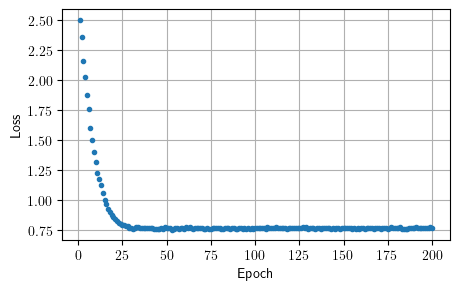

In [12]:
fig, axs = plt.subplots(1, 1, figsize=(5, 3))

loss = diffusion_process.trainer.train_history['loss']
epochs = np.arange(1, len(loss) + 1)
plt.plot(epochs, loss, '.')


plt.grid()
plt.xlabel("Epoch")
plt.ylabel("Loss")

In [13]:
num_samples, *sample_shape, n_c, n_c = training_samples.shape

from normflow.prior import SUnPrior
prior = SUnPrior(n_c, sample_shape)

x = prior.sample(32)
t_eval = torch.linspace(1, -1, 10)


with torch.no_grad():
    y_eval = diffusion_process.reverse(x, rev2fwd_noise_ratio=1, step_size=0.01, t_eval=t_eval)


y = y_eval[-1]  # This is the state at the final time of t_eval, i.e. at t = 0

In [14]:
from lattice_ml.gauge_tools import compute_wilson_1x1_loop
from lattice_ml.linalg import eigu


theta_x = eigu(compute_wilson_1x1_loop(x, 0, 1))[0].angle()
theta_y = eigu(compute_wilson_1x1_loop(y, 0, 1))[0].angle()

theta_training = eigu(compute_wilson_1x1_loop(training_samples, 0, 1))[0].angle()

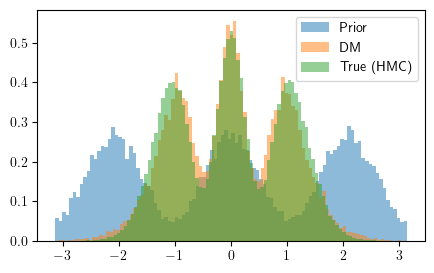

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))

grab = lambda z: z.detach().cpu().numpy()

plt.hist(grab(theta_x).ravel(), label = 'Prior', bins=100, density=True, alpha=0.5)
plt.hist(grab(theta_y).ravel(), label = 'DM', bins=100, density=True, alpha=0.5)
plt.hist(grab(theta_training).ravel(), label = 'True (HMC)', bins=100, density=True, alpha=0.5)

plt.legend();

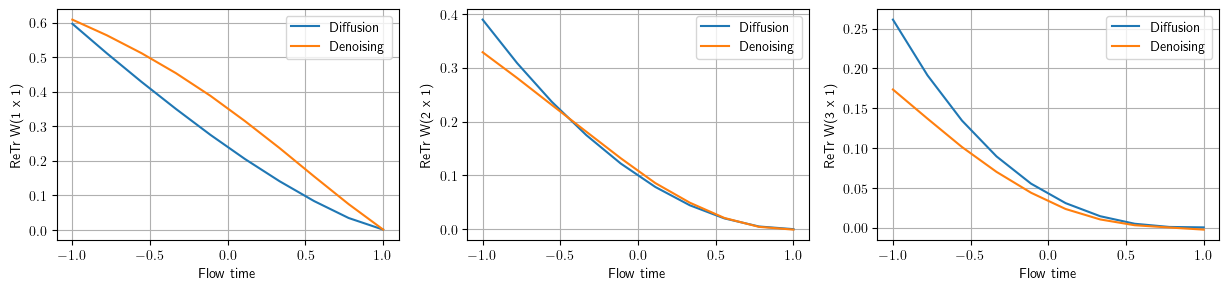

In [16]:
fig, axs = plt.subplots(1, 3, figsize=(15, 3))


t_eval = torch.flip(t_eval, dims=(0,))
denoised_samples = torch.flip(torch.stack(y_eval, dim=0), dims=(0,))

plot_wilson_loops(t_eval, diffused_samples, label='Diffusion', axs=axs)
plot_wilson_loops(t_eval, denoised_samples, label='Denoising', axs=axs)

for ax in axs:
    ax.grid()

# fig, axs = plot_3subplots_diffusion(t_eval, denoised_samples)

In [17]:
diffusion_process.score_fn.weight * 16 / 3

tensor(1.0988, grad_fn=<DivBackward0>)